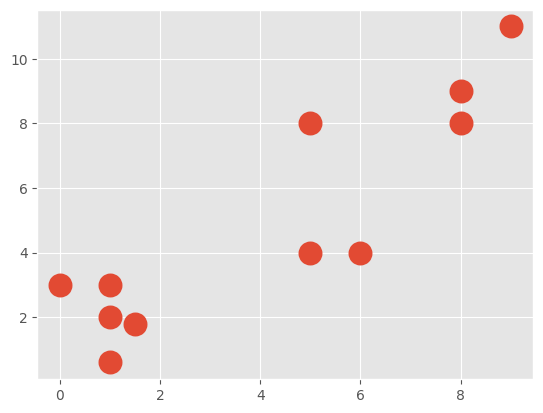

In [58]:
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
import numpy as np


X = np.array([[1,2],
              [1.5, 1.8],
              [5, 8],
              [8,8],
              [1, 0.6],
              [9,11],
              [1,3],
              [8,9],
              [0,3],
              [5,4],
              [6,4]])



plt.scatter(X[:,0],X[:,1], s=150, linewidths=5)
plt.show()

colors = ['g','r','c','b','k']

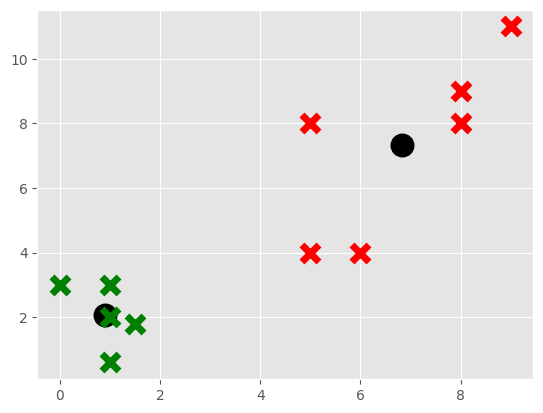

In [59]:
class K_Means:
    def __init__(self, k=2, tol=0.001, max_iter=300):
        self.k = k
        self.tol = tol
        self.max_iter = max_iter

    
    def fit(self, data):
        self.centroids = {}

        for i in range(self.k):
            self.centroids[i] = data[i]
        
        for i in range(self.max_iter):
            self.classifications = {}

            for i in range(self.k):
                self.classifications[i] = []
            
            for featureset in X:
                distances = [np.linalg.norm(featureset-self.centroids[centroid]) for centroid in self.centroids]
                classification = distances.index(min(distances))
                self.classifications[classification].append(featureset)

            prev_centroids = dict(self.centroids)


            for classification in self.classifications:
                self.centroids[classification] = np.average(self.classifications[classification], axis=0)

            optimized = True

            for c in self.centroids:
                original_centroids = prev_centroids[c]
                Current_centroid = self.centroids[c]
                if np.sum((Current_centroid-original_centroids)/original_centroids*100)>self.tol:
                    optimized =False
            
            if optimized:
                break

    def predict(self, data):
        distances = [np.linalg.norm(data-self.centroids[centroid]) for centroid in self.centroids]
        classification = distances.index(min(distances))
        return classification
    

clf = K_Means()
clf.fit(X)

for centroid in clf.centroids:
    plt.scatter(clf.centroids[centroid][0], clf.centroids[centroid][1], marker='o', color='k', s=150, linewidths=5)

for classification in clf.classifications:
    color = colors[classification]
    for featureset in clf.classifications[classification]:
       plt.scatter(featureset[0], featureset[1], marker='x', color=color, s=150, linewidths=5)
 

# unknowns = np.array([[1,3],[8,9],[0,3],[5,4],[6,4]])

# for unknown in unknowns:
#     classification = clf.predict(unknown)
#     plt.scatter(unknown[0],unknown[1], marker='*', color=colors[classification], s=150, linewidths=5)

# plt.show()

# plt.show()

In [60]:
# unknowns = np.array([[1,3],[8,9],[0,3],[5,4],[6,4]])

# for unknown in unknowns:
#     classification = clf.predict(unknown)
#     plt.scatter(unknown[0],unknown[1], marker='*', color=colors[classification], s=150, linewidths=5)

# plt.show()

using titanic Dataset


In [61]:
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import pandas as pd


df = pd.read_excel('../../Data/titanic.xls')
df.drop(['body','name'], axis=1, inplace=True)
df = df.infer_objects()
df.fillna(0, inplace=True)

In [62]:
def handle_non_numerical_data(df):
    columns = df.columns.values

    for column in columns:
        text_digit_vals = {}
        def convert_to_int(val): 
            return text_digit_vals[val]
        
        if df[column].dtype != np.int64 and df[column].dtype != np.float64:
            column_contents = df[column].values.tolist()
            unique_elements = set(column_contents)
            x=0
            for unique in unique_elements:
                if unique not in text_digit_vals:
                    text_digit_vals[unique] =x
                    x+=1
            
            df[column] = list(map(convert_to_int, df[column]))
    
    return df

df = handle_non_numerical_data(df)
df.head()

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest
0,1,1,0,29.0000,0,0,756,211.3375,27,1,2,227
1,1,1,1,0.9167,1,2,512,151.5500,176,1,17,272
2,1,0,0,2.0000,1,2,512,151.5500,176,1,0,272
3,1,0,1,30.0000,1,2,512,151.5500,176,1,0,272
4,1,0,0,25.0000,1,2,512,151.5500,176,1,0,272


In [63]:
df.drop(['boat', 'sex'], axis=1, inplace=True)
X = np.array(df.drop(['survived'], axis=1).astype(float))
X = preprocessing.scale(X)
y = np.array(df['survived'])

clf = K_Means()
clf.fit(X)


correct = 0
for i in range(len(X)):
    predict_me = np.array(X[i].astype(float))
    predict_me = predict_me.reshape(-1, len(predict_me))
    prediction = clf.predict(predict_me)
    if prediction == y[i] :
        correct +=1


print(correct/len(X))

0.6432391138273491
